# 01. ETER EDA

Первинний розвідувальний аналіз бази ETER на основі підготовлених таблиць із `data/processed`.


## Мета

Зрозуміти структуру, якість та аналітичний потенціал підготовлених даних ETER перед побудовою підсумкових таблиць, порівнянь і візуалізацій.

Основне джерело даних: `../data/processed/`.


## 1. Підготовка середовища

In [1]:
from pathlib import Path
import os
import tempfile
import warnings

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
MPLCONFIG_DIR = Path(tempfile.gettempdir()) / "eter-matplotlib-cache"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", context="notebook")

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {DATA_DIR}")
print(f"Figures output: {FIGURES_DIR}")

Project root: /Users/ssyvon41kkk/PycharmProjects/ETER.EDBO.v2
Processed data: /Users/ssyvon41kkk/PycharmProjects/ETER.EDBO.v2/data/processed
Figures output: /Users/ssyvon41kkk/PycharmProjects/ETER.EDBO.v2/figures


## 2. Завантаження ETER-таблиць

Завантажуємо тільки ETER-орієнтовані таблиці. Файли EDBO в цьому ноутбуці не використовуються.


In [2]:
ETER_TABLE_FILES = [
    "df_base.csv",
    "df_base_clean.csv",
    "eter_institution_metrics.csv",
    "country_overview.csv",
    "country_profiles.csv",
    "country_metric_availability.csv",
    "country_metric_exclusions.csv",
    "country_metrics_descriptive_stats.csv",
    "country_ranking_exclusions.csv",
    "eda_input_tables_overview.csv",
    "finance_staff_anomalies.csv",
    "finance_staff_metrics.csv",
    "overview_data_quality.csv",
    "special_codes.csv",
    "student_structure_anomalies.csv",
    "student_structure_metrics.csv",
    "student_structure_quality_checks.csv",
    "students_funding_per_student_correlation_all_heis_2022_2023.csv",
    "students_funding_per_student_correlation_by_country_2022_2023.csv",
    "students_funding_per_student_correlation_by_year_2022_2023.csv",
    "students_funding_per_student_country_counts_2022_2023.csv",
    "students_funding_per_student_exclusions_2022_2023.csv",
    "students_funding_per_student_input_2022_2023.csv",
    "students_students_per_teacher_correlation_all_heis_2022_2023.csv",
    "students_students_per_teacher_correlation_by_country_2022_2023.csv",
    "students_students_per_teacher_correlation_by_year_2022_2023.csv",
    "students_students_per_teacher_country_counts_2022_2023.csv",
    "students_students_per_teacher_exclusions_2022_2023.csv",
    "students_students_per_teacher_input_2022_2023.csv",
    "median_students_funding_per_student_correlation.csv",
    "median_students_funding_per_student_correlation_by_year.csv",
    "median_students_funding_per_student_country_year.csv",
    "median_students_per_teacher_funding_per_student_correlation_all_heis_2022_2023.csv",
    "median_students_students_per_teacher_correlation_all_heis_2022_2023.csv",
    "education_funding_per_student_by_country_group_wide_latest_year.csv",
    "education_funding_per_student_by_country_group_years_wide.csv",
    "education_funding_per_student_ppp_by_country_group_wide_latest_year.csv",
    "education_funding_per_student_ppp_by_country_group_years_wide.csv",
    "students_per_teacher_by_country_group_wide_latest_year.csv",
    "students_per_teacher_by_country_group_years_wide.csv",
]

def read_processed_csv(path: Path) -> pd.DataFrame:
    first_line = path.read_text(encoding="utf-8-sig", errors="replace").splitlines()[0]
    sep = ";" if first_line.count(";") > first_line.count(",") else ","
    df = pd.read_csv(path, encoding="utf-8-sig", sep=sep, low_memory=False)
    df.columns = df.columns.str.replace("\ufeff", "", regex=False).str.strip()
    return df

tables = {}
missing_files = []
for file_name in ETER_TABLE_FILES:
    path = DATA_DIR / file_name
    if path.exists():
        tables[path.stem] = read_processed_csv(path)
    else:
        missing_files.append(file_name)

tables_overview = pd.DataFrame(
    [
        {
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "country_count": df["country_code"].nunique() if "country_code" in df else np.nan,
            "year_min": df["year"].min() if "year" in df else np.nan,
            "year_max": df["year"].max() if "year" in df else np.nan,
        }
        for name, df in tables.items()
    ]
).sort_values(["rows", "columns"], ascending=False)

display(tables_overview)
if missing_files:
    display(Markdown("**Не найдены файлы:** " + ", ".join(missing_files)))

,table,rows,columns,country_count,year_min,year_max
2,eter_institution_metrics,29591,91,40.000,2013.000,2023.000
0,df_base,29591,57,40.000,2013.000,2023.000
1,df_base_clean,29591,57,40.000,2013.000,2023.000
14,student_structure_anomalies,12035,18,29.000,2013.000,2023.000
28,students_students_per_teacher_input_2022_2023,1915,7,27.000,2022.000,2023.000
22,students_funding_per_student_input_2022_2023,1366,9,26.000,2022.000,2023.000
6,country_metric_exclusions,1126,6,35.000,2013.000,2023.000
4,country_profiles,376,143,40.000,2013.000,2023.000
11,finance_staff_metrics,376,75,40.000,2013.000,2023.000
15,student_structure_metrics,376,57,40.000,2013.000,2023.000


## 3. Структура бази

In [3]:
base = tables["df_base"]
base_clean = tables["df_base_clean"]
institution_metrics = tables["eter_institution_metrics"]
country_overview = tables["country_overview"]
student_metrics = tables["student_structure_metrics"]
finance_metrics = tables["finance_staff_metrics"]

key_columns = [
    "record_id", "institution_id", "institution_name_en", "year", "country_code",
    "institution_category_en", "students_total_analysis", "academic_personnel_fte",
    "student_staff_ratio", "expenditure_per_student_ppp", "foreign_students_share",
]
available_key_columns = [col for col in key_columns if col in institution_metrics.columns]

display(Markdown("### Институциональная таблица"))
display(institution_metrics[available_key_columns].head(10))

structure_summary = pd.DataFrame(
    {
        "metric": [
            "records",
            "institutions",
            "countries",
            "year_min",
            "year_max",
            "institution_categories",
        ],
        "value": [
            len(institution_metrics),
            institution_metrics["institution_id"].nunique(),
            institution_metrics["country_code"].nunique(),
            int(institution_metrics["year"].min()),
            int(institution_metrics["year"].max()),
            institution_metrics["institution_category_en"].nunique(),
        ],
    }
)
display(Markdown("### Общая структура"))
display(structure_summary)

### Институциональная таблица

,record_id,institution_id,institution_name_en,year,country_code,institution_category_en,students_total_analysis,academic_personnel_fte,student_staff_ratio,expenditure_per_student_ppp,foreign_students_share
0,AD0001.2023,AD0001,University of Andorra,2023,AD,University,675.000,NaN,NaN,7463.773,NaN
1,AL0001.2023,AL0001,University of Tirana,2023,AL,University,NaN,NaN,NaN,NaN,NaN
2,AL0002.2023,AL0002,Polytechnic University of Tirana,2023,AL,University,NaN,NaN,NaN,NaN,NaN
3,AL0003.2023,AL0003,Agricultural University of Tirana,2023,AL,University,NaN,NaN,NaN,NaN,NaN
4,AL0004.2023,AL0004,"University of Elbasan, Aleksander Xhuvani",2023,AL,University,NaN,NaN,NaN,NaN,NaN
5,AL0005.2023,AL0005,"University of Shkodra ""Luigj Gurakuqi""",2023,AL,University,NaN,NaN,NaN,NaN,NaN
6,AL0006.2023,AL0006,"University ""Eqrem Çabej"" Gjirokastra",2023,AL,University,NaN,NaN,NaN,NaN,NaN
7,AL0007.2023,AL0007,"""Fan. S. Noli"" University of Korçë",2023,AL,University,NaN,NaN,NaN,NaN,NaN
8,AL0008.2023,AL0008,"""Ismail Qemali"" University of Vlora",2023,AL,University,NaN,NaN,NaN,NaN,NaN
9,AL0009.2023,AL0009,"""Aleksandër Moisiu"" University of Durrës",2023,AL,University,NaN,NaN,NaN,NaN,NaN


### Общая структура

,metric,value
0,records,29591
1,institutions,4037
2,countries,40
3,year_min,2013
4,year_max,2023
5,institution_categories,119


## 4. Якість даних

Перевіряємо пропуски, готові таблиці перевірки якості, доступність метрик і винятки.


In [4]:
analysis_columns = [
    "students_total_analysis",
    "students_total_calc",
    "academic_personnel_fte",
    "total_personnel_fte",
    "student_staff_ratio",
    "total_current_expenditure_ppp",
    "total_current_revenues_ppp",
    "expenditure_per_student_ppp",
    "revenue_per_student_ppp",
    "foreign_students_share",
    "isced5_share",
    "isced6_share",
    "isced7_share",
    "isced8_share",
    "phd_share",
]
analysis_columns = [col for col in analysis_columns if col in institution_metrics.columns]

missing_summary = (
    institution_metrics[analysis_columns]
    .isna()
    .mean()
    .mul(100)
    .rename("missing_pct")
    .rename_axis("column")
    .reset_index()
    .sort_values("missing_pct", ascending=False)
)

duplicates_summary = pd.DataFrame(
    {
        "check": ["duplicate record_id", "duplicate institution-year"],
        "affected_rows": [
            institution_metrics.duplicated("record_id").sum(),
            institution_metrics.duplicated(["institution_id", "year"]).sum(),
        ],
    }
)

display(Markdown("### Пропуски в ключевых метриках"))
display(missing_summary)
display(Markdown("### Дубликаты"))
display(duplicates_summary)

for table_name in ["overview_data_quality", "student_structure_quality_checks", "country_metric_availability", "country_metric_exclusions", "special_codes"]:
    if table_name in tables:
        display(Markdown(f"### `{table_name}`"))
        display(tables[table_name].head(20))

### Пропуски в ключевых метриках

,column,missing_pct
7,expenditure_per_student_ppp,57.213
8,revenue_per_student_ppp,56.615
5,total_current_expenditure_ppp,56.051
6,total_current_revenues_ppp,55.459
3,total_personnel_fte,53.641
4,student_staff_ratio,43.926
2,academic_personnel_fte,43.581
9,foreign_students_share,22.193
10,isced5_share,20.226
11,isced6_share,20.226


### Дубликаты

,check,affected_rows
0,duplicate record_id,0
1,duplicate institution-year,0


### `overview_data_quality`

...

,metric,country_years_available,share_available
0,institutions_count,376.000,1.000
1,institutions_with_student_data,376.000,1.000
2,student_coverage_share,376.000,1.000
3,total_students,360.000,0.957
4,avg_observed_institution_size,360.000,0.957
5,students_per_registered_institution,360.000,0.957
6,median_institution_size,360.000,0.957
7,foreign_students_share,308.000,0.819
8,isced5_share,285.000,0.758
9,isced6_share,285.000,0.758


### `country_metric_exclusions`

,country_code,year,metric,exclusion_reason,student_coverage_share,complete_isced_structure_share
0,AD,2017,total_students,metric_missing_or_unreliable_after_coverage_fi...,NaN,NaN
1,AL,2022,total_students,metric_missing_or_unreliable_after_coverage_fi...,NaN,NaN
2,AL,2023,total_students,metric_missing_or_unreliable_after_coverage_fi...,NaN,NaN
3,DK,2014,total_students,metric_missing_or_unreliable_after_coverage_fi...,NaN,NaN
4,FR,2015,total_students,metric_missing_or_unreliable_after_coverage_fi...,NaN,NaN
5,FR,2018,total_students,metric_missing_or_unreliable_after_coverage_fi...,NaN,NaN
6,IS,2015,total_students,metric_missing_or_unreliable_after_coverage_fi...,NaN,NaN
7,IS,2016,total_students,metric_missing_or_unreliable_after_coverage_fi...,NaN,NaN
8,ME,2014,total_students,metric_missing_or_unreliable_after_coverage_fi...,NaN,NaN
9,ME,2015,total_students,metric_missing_or_unreliable_after_coverage_fi...,NaN,NaN


### `special_codes`

,Special code,Label
0,a,not applicable
1,m,information missing
2,x,"breakdown not available, but included in total"
3,xc,included in another subcolumn
4,xr,included in another row
5,nc,"Data not collected, since variables was introd..."
6,c,confidential
7,s,value larger than 0 and below or equal to 3 re...


## 5. Порівняння `df_base.csv` і `df_base_clean.csv`

In [5]:
common_columns = [col for col in base.columns if col in base_clean.columns]
base_missing = base[common_columns].isna().sum()
clean_missing = base_clean[common_columns].isna().sum()

cleaning_impact = (
    pd.DataFrame(
        {
            "base_missing": base_missing,
            "clean_missing": clean_missing,
            "missing_delta_clean_minus_base": clean_missing - base_missing,
            "base_dtype": base[common_columns].dtypes.astype(str),
            "clean_dtype": base_clean[common_columns].dtypes.astype(str),
        }
    )
    .rename_axis("column")
    .reset_index()
)
cleaning_impact = cleaning_impact[
    (cleaning_impact["missing_delta_clean_minus_base"] != 0)
    | (cleaning_impact["base_dtype"] != cleaning_impact["clean_dtype"])
].sort_values("missing_delta_clean_minus_base", ascending=False)

display(Markdown("### Поля, изменившиеся после очистки"))
display(cleaning_impact)

shape_comparison = pd.DataFrame(
    {
        "table": ["df_base", "df_base_clean"],
        "rows": [len(base), len(base_clean)],
        "columns": [base.shape[1], base_clean.shape[1]],
    }
)
display(Markdown("### Размеры таблиц"))
display(shape_comparison)

### Поля, изменившиеся после очистки

,column,base_missing,clean_missing,missing_delta_clean_minus_base,base_dtype,clean_dtype
37,rd_expenditure_ppp,0,19291,19291,str,float64
36,rd_expenditure_eur,0,19291,19291,str,float64
35,third_party_funding_ppp,0,17490,17490,str,float64
34,third_party_funding_eur,0,17490,17490,str,float64
31,total_current_expenditure_ppp,0,16586,16586,str,float64
30,total_current_expenditure_eur,0,16586,16586,str,float64
33,total_current_revenues_ppp,0,16411,16411,str,float64
32,total_current_revenues_eur,0,16411,16411,str,float64
29,support_admin_personnel_fte,0,16304,16304,str,float64
28,total_personnel_fte,0,15873,15873,str,float64


### Размеры таблиц

,table,rows,columns
0,df_base,29591,57
1,df_base_clean,29591,57


## 6. Покриття за країнами та роками

In [6]:
year_coverage = (
    institution_metrics.groupby("year")
    .agg(
        records=("record_id", "count"),
        institutions=("institution_id", "nunique"),
        countries=("country_code", "nunique"),
        records_with_students=("students_total_analysis", lambda s: s.notna().sum()),
    )
    .reset_index()
)
year_coverage["student_record_coverage"] = year_coverage["records_with_students"] / year_coverage["records"]

country_coverage = (
    institution_metrics.groupby("country_code")
    .agg(
        records=("record_id", "count"),
        institutions=("institution_id", "nunique"),
        years=("year", "nunique"),
        year_min=("year", "min"),
        year_max=("year", "max"),
        records_with_students=("students_total_analysis", lambda s: s.notna().sum()),
    )
    .reset_index()
)
country_coverage["student_record_coverage"] = country_coverage["records_with_students"] / country_coverage["records"]

display(Markdown("### Покрытие по годам"))
display(year_coverage)
display(Markdown("### Топ стран по числу институций"))
display(country_coverage.sort_values("institutions", ascending=False).head(20))

### Покрытие по годам

,year,records,institutions,countries,records_with_students,student_record_coverage
0,2013,62,62,2,59,0.952
1,2014,2880,2880,37,2707,0.940
2,2015,2989,2989,37,2458,0.822
3,2016,2588,2588,36,2478,0.957
4,2017,2904,2904,39,2747,0.946
5,2018,2903,2903,39,2547,0.877
6,2019,2892,2892,39,2745,0.949
7,2020,2809,2809,37,2660,0.947
8,2021,2962,2962,37,2853,0.963
9,2022,3439,3439,38,3302,0.960


### Топ стран по числу институций

,country_code,records,institutions,years,year_min,year_max,records_with_students,student_record_coverage
13,FR,3532,989,9,2014,2023,2880,0.815
8,DE,3977,421,10,2014,2023,3977,1.000
29,PL,2316,312,9,2014,2022,2316,1.000
37,UK,2445,282,10,2014,2023,2445,1.000
36,TR,1987,231,10,2014,2023,1943,0.978
19,IT,2101,223,10,2014,2023,2100,1.000
3,BE,1223,152,10,2014,2023,501,0.410
30,PT,919,113,10,2014,2023,919,1.000
31,RO,926,99,10,2014,2023,674,0.728
11,ES,843,91,10,2014,2023,843,1.000


## 7. EDA за інституціями

In [7]:
institution_numeric_metrics = [
    "students_total_analysis",
    "academic_personnel_fte",
    "student_staff_ratio",
    "foreign_students_share",
    "revenue_per_student_ppp",
    "expenditure_per_student_ppp",
    "rd_expenditure_per_student_ppp",
]
institution_numeric_metrics = [col for col in institution_numeric_metrics if col in institution_metrics.columns]

display(Markdown("### Описательная статистика институциональных метрик"))
display(institution_metrics[institution_numeric_metrics].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T)

category_summary = (
    institution_metrics.groupby("institution_category_en", dropna=False)
    .agg(records=("record_id", "count"), institutions=("institution_id", "nunique"))
    .sort_values("records", ascending=False)
    .reset_index()
)
display(Markdown("### Категории институций"))
display(category_summary)

latest_year = int(institution_metrics["year"].max())
latest_institutions = institution_metrics[institution_metrics["year"] == latest_year].copy()
latest_country_summary = (
    latest_institutions.groupby("country_code")
    .agg(
        institutions=("institution_id", "nunique"),
        students=("students_total_analysis", "sum"),
        median_students=("students_total_analysis", "median"),
        median_student_staff_ratio=("student_staff_ratio", "median"),
        median_expenditure_per_student_ppp=("expenditure_per_student_ppp", "median"),
    )
    .reset_index()
    .sort_values("students", ascending=False)
)
display(Markdown(f"### Срез по странам за последний год в данных: {latest_year}"))
display(latest_country_summary.head(25))

### Описательная статистика институциональных метрик

,count,mean,std,min,1%,25%,50%,75%,99%,max
students_total_analysis,27590.000,9420.988,59407.900,0.000,0.000,574.000,2442.000,10450.000,63659.660,3538594.000
academic_personnel_fte,16695.000,576.157,925.940,0.000,5.000,57.000,198.300,665.000,4655.600,7617.720
student_staff_ratio,16593.000,19.690,18.674,0.000,2.635,10.679,15.867,22.436,97.305,647.000
foreign_students_share,23024.000,0.116,0.154,0.000,0.000,0.018,0.064,0.148,0.811,1.000
revenue_per_student_ppp,12838.000,19458.470,183574.174,0.000,1268.368,6135.339,8981.656,14853.585,88399.463,10932245.152
expenditure_per_student_ppp,12661.000,17953.463,160590.455,0.000,1249.627,5948.712,8587.322,14188.271,82289.224,10395704.912
rd_expenditure_per_student_ppp,9504.000,1388.723,8359.920,0.000,0.000,0.000,0.000,344.538,19292.157,271033.609


### Категории институций

,institution_category_en,records,institutions
0,University,7627,871
1,University of applied sciences,2665,292
2,Public university,2122,219
3,Other HEIs Supervised by the Minister Responsi...,1550,225
4,University college,1089,122
...,...,...,...
115,Private faculty,1,1
116,Independent state faculty,1,1
117,Higher institute for musical and choreographic...,1,1
118,Further and Higher Education Institution,1,1


### Срез по странам за последний год в данных: 2023

,country_code,institutions,students,median_students,median_student_staff_ratio,median_expenditure_per_student_ppp
32,TR,208,7081289.000,15557.500,NaN,NaN
33,UK,245,2883545.000,6885.000,17.750,10512.760
8,DE,400,2866239.000,2964.000,15.302,9948.161
13,FR,816,2545897.000,480.000,NaN,8857.462
19,IT,209,2262370.000,1090.000,8.585,NaN
11,ES,91,1757811.000,13796.000,15.920,NaN
14,GR,43,882145.000,14165.000,NaN,NaN
25,NL,57,803050.000,4965.000,16.337,14251.888
30,SE,39,598370.000,12655.000,22.928,9073.900
28,RO,90,525885.000,2315.000,11.456,NaN


## 8. EDA за країнами та роками

In [8]:
country_year_metrics = country_overview.merge(
    student_metrics[["country_code", "year", "student_coverage_share", "complete_isced_structure_share", "foreign_students_share"]],
    on=["country_code", "year"],
    how="left",
    suffixes=("", "_student_metrics"),
).merge(
    finance_metrics[["country_code", "year", "student_staff_ratio", "expenditure_per_student_ppp", "revenue_per_student_ppp"]],
    on=["country_code", "year"],
    how="left",
)

display(Markdown("### Country-year метрики"))
display(country_year_metrics.head(20))

latest_country_year = country_year_metrics[country_year_metrics["year"] == country_year_metrics["year"].max()].copy()
country_metric_columns = [
    "total_students",
    "institutions_count",
    "student_coverage_share",
    "complete_isced_structure_share",
    "student_staff_ratio",
    "expenditure_per_student_ppp",
    "foreign_students_share",
]
country_metric_columns = [col for col in country_metric_columns if col in latest_country_year.columns]
display(Markdown("### Описательная статистика по странам за последний год"))
display(latest_country_year[country_metric_columns].describe().T)

### Country-year метрики

,country_code,year,records,institutions_count,total_students,students_isced5_7_total,students_isced8,mean_observed_institution_size,median_institution_size,min_institution_size,max_institution_size,foreign_students,academic_personnel_fte,total_personnel_fte,total_current_revenues_eur,total_current_expenditure_eur,total_current_revenues_ppp,total_current_expenditure_ppp,institutions_with_student_data,student_coverage_share,avg_observed_institution_size,students_per_registered_institution,avg_institution_size,foreign_students_share,student_staff_ratio_x,revenue_per_student_eur,expenditure_per_student_eur,revenue_per_student_ppp_x,expenditure_per_student_ppp_x,student_coverage_share_student_metrics,complete_isced_structure_share,foreign_students_share_student_metrics,student_staff_ratio_y,expenditure_per_student_ppp_y,revenue_per_student_ppp_y
0,AD,2017,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN,NaN
1,AD,2018,2,2,541.000,519.000,22.000,541.000,541.000,541.000,541.000,NaN,NaN,NaN,3343654.000,3343654.000,3588882.330,3588882.330,1,0.500,541.000,270.500,270.500,NaN,NaN,6180.506,6180.506,6633.794,6633.794,0.500,0.000,NaN,NaN,6633.794,6633.794
2,AD,2019,2,2,569.000,546.000,23.000,569.000,569.000,569.000,569.000,NaN,NaN,NaN,3574855.000,3574855.000,3848548.366,3848548.366,1,0.500,569.000,284.500,284.500,NaN,NaN,6282.698,6282.698,6763.705,6763.705,0.500,0.000,NaN,NaN,6763.705,6763.705
3,AD,2020,2,2,547.000,524.000,23.000,547.000,547.000,547.000,547.000,NaN,NaN,NaN,3743096.000,3743096.000,3944032.630,3944032.630,1,0.500,547.000,273.500,273.500,NaN,NaN,6842.954,6842.954,7210.297,7210.297,0.500,0.000,NaN,NaN,7210.297,7210.297
4,AD,2021,1,1,629.000,610.000,19.000,629.000,629.000,629.000,629.000,NaN,NaN,NaN,3749057.000,3749057.000,4063833.408,4063833.408,1,1.000,629.000,629.000,629.000,NaN,NaN,5960.345,5960.345,6460.784,6460.784,1.000,0.000,NaN,NaN,6460.784,6460.784
5,AD,2022,1,1,674.000,651.000,23.000,674.000,674.000,674.000,674.000,NaN,NaN,NaN,3982353.000,3982353.000,4395770.853,4395770.853,1,1.000,674.000,674.000,674.000,NaN,NaN,5908.536,5908.536,6521.915,6521.915,1.000,0.000,NaN,NaN,6521.915,6521.915
6,AD,2023,1,1,675.000,651.000,24.000,675.000,675.000,675.000,675.000,NaN,NaN,NaN,4488648.000,4488648.000,5038047.028,5038047.028,1,1.000,675.000,675.000,675.000,NaN,NaN,6649.849,6649.849,7463.773,7463.773,1.000,0.000,NaN,NaN,7463.773,7463.773
7,AL,2013,38,38,163530.000,163530.000,NaN,4672.286,730.000,20.000,37650.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35,0.921,4672.286,4303.421,4303.421,NaN,NaN,NaN,NaN,NaN,NaN,0.921,0.000,NaN,NaN,NaN,NaN
8,AL,2014,38,38,163530.000,163530.000,0.000,4303.421,692.500,0.000,37650.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,38,1.000,4303.421,4303.421,4303.421,0.000,NaN,NaN,NaN,NaN,NaN,1.000,0.000,0.000,NaN,NaN,NaN
9,AL,2015,40,40,146075.000,143545.000,2530.000,3651.875,760.000,0.000,30470.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40,1.000,3651.875,3651.875,3651.875,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.175,NaN,NaN,NaN,NaN


### Описательная статистика по странам за последний год

,count,mean,std,min,25%,50%,75%,max
total_students,34.000,775675.240,1388236.014,675.000,60453.500,289124.500,580236.250,7081289.000
institutions_count,35.000,90.371,150.500,1.000,31.000,41.000,83.000,816.000
student_coverage_share,35.000,0.942,0.198,0.000,1.000,1.000,1.000,1.000
complete_isced_structure_share,35.000,0.808,0.328,0.000,0.787,0.995,1.000,1.000
foreign_students_share,31.000,0.174,0.192,0.000,0.078,0.112,0.170,0.904


## 9. Зв'язки між ключовими метриками

In [9]:
corr_metrics = [
    "students_total_analysis",
    "academic_personnel_fte",
    "student_staff_ratio",
    "foreign_students_share",
    "revenue_per_student_ppp",
    "expenditure_per_student_ppp",
    "rd_expenditure_per_student_ppp",
]
corr_metrics = [col for col in corr_metrics if col in institution_metrics.columns]
institution_corr = institution_metrics[corr_metrics].corr(method="spearman", min_periods=30)

display(Markdown("### Spearman correlation, institution level"))
display(institution_corr)

for table_name in [
    "students_funding_per_student_correlation_all_heis_2022_2023",
    "students_students_per_teacher_correlation_all_heis_2022_2023",
    "median_students_funding_per_student_correlation",
]:
    if table_name in tables:
        display(Markdown(f"### Готовая таблица корреляций: `{table_name}`"))
        display(tables[table_name])

### Spearman correlation, institution level

,students_total_analysis,academic_personnel_fte,student_staff_ratio,foreign_students_share,revenue_per_student_ppp,expenditure_per_student_ppp,rd_expenditure_per_student_ppp
students_total_analysis,1.000,0.907,0.165,0.104,-0.015,-0.070,0.548
academic_personnel_fte,0.907,1.000,-0.216,0.172,0.274,0.210,0.700
student_staff_ratio,0.165,-0.216,1.000,-0.169,-0.672,-0.705,-0.334
foreign_students_share,0.104,0.172,-0.169,1.000,0.389,0.390,0.149
revenue_per_student_ppp,-0.015,0.274,-0.672,0.389,1.000,0.957,0.446
expenditure_per_student_ppp,-0.070,0.210,-0.705,0.390,0.957,1.000,0.463
rd_expenditure_per_student_ppp,0.548,0.700,-0.334,0.149,0.446,0.463,1.000


### Готовая таблица корреляций: `students_funding_per_student_correlation_all_heis_2022_2023`

,group,method,correlation,p_value,n_institutions
0,all_heis,pearson,-0.038,0.164,1366
1,all_heis,spearman,-0.100,0.000,1366


### Готовая таблица корреляций: `students_students_per_teacher_correlation_all_heis_2022_2023`

,group,method,correlation,p_value,n_institutions
0,all_heis,pearson,0.129,0.000,1915
1,all_heis,spearman,0.259,0.000,1915


### Готовая таблица корреляций: `median_students_funding_per_student_correlation`

,method,correlation,p_value,n_country_years,n_countries
0,pearson,0.060,0.394,207,26
1,spearman,0.265,0.000,207,26


## 10. Візуалізації

Усі графіки зберігаються в загальній папці `figures/`. Імена файлів із цього ноутбука починаються з `01_`.


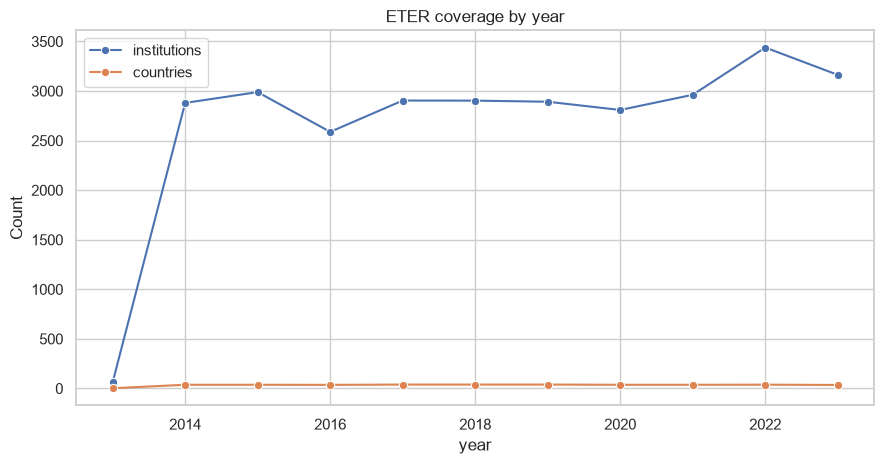

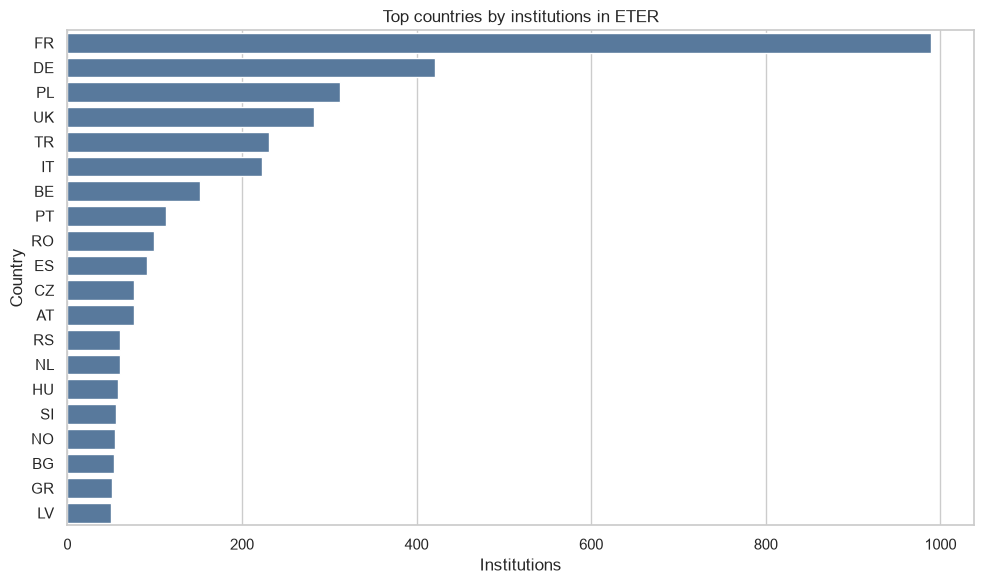

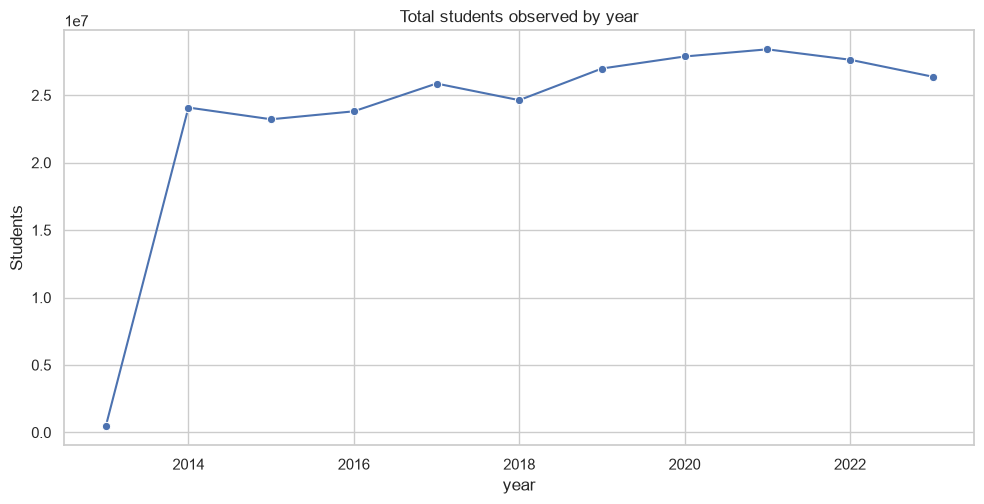

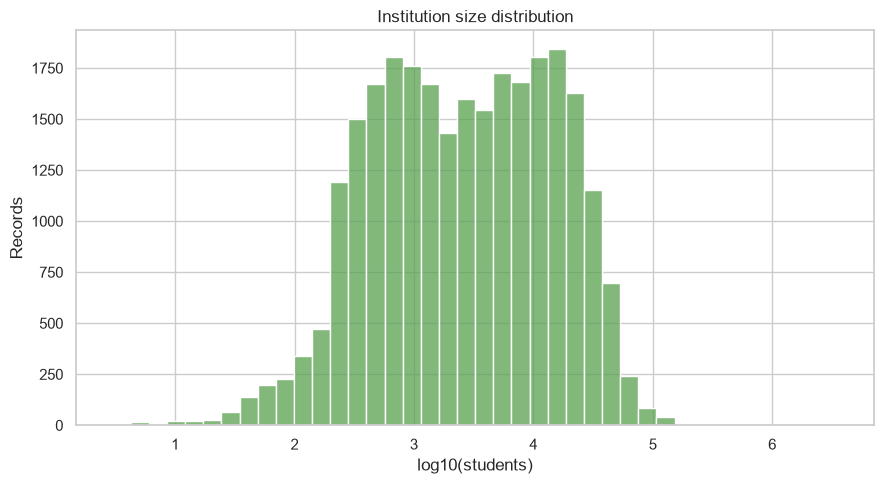

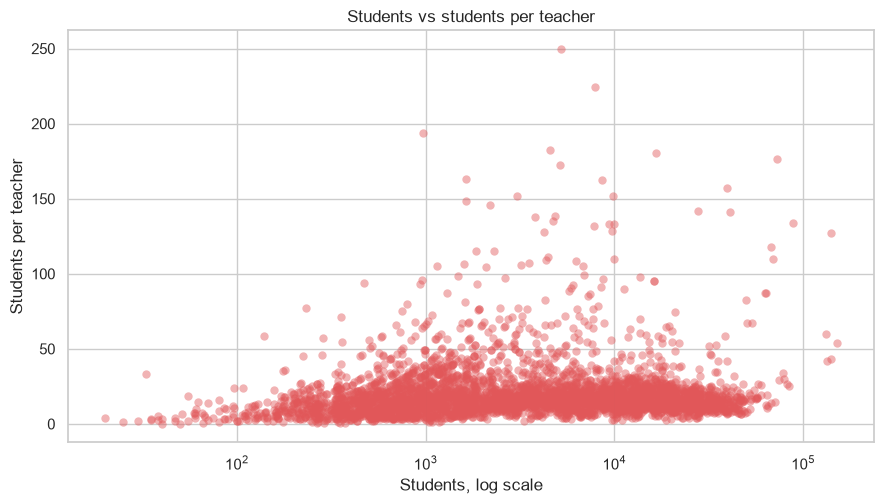

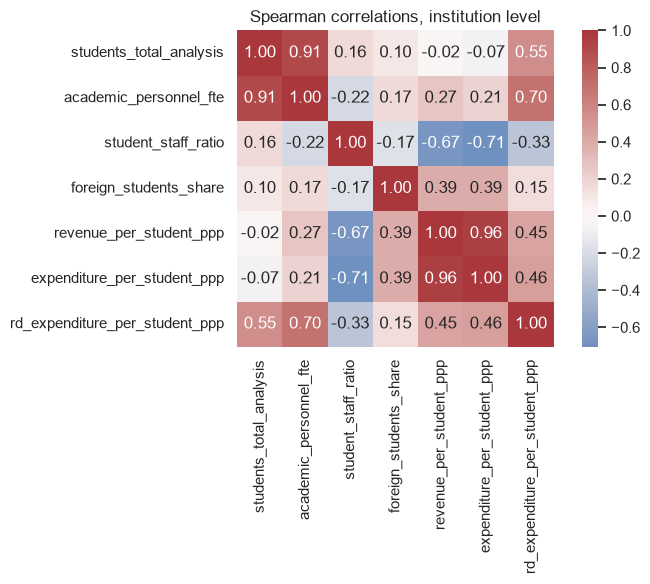

### Saved figures

,figure
0,figures/01_eter_coverage_by_year.png
1,figures/01_eter_top_countries_by_institutions.png
2,figures/01_eter_total_students_by_year.png
3,figures/01_eter_institution_size_distribution.png
4,figures/01_eter_students_vs_students_per_teach...
5,figures/01_eter_institution_correlation_heatma...


In [10]:
NOTEBOOK_PREFIX = "01_"
saved_figures = []

def save_current_figure(file_name: str) -> None:
    normalized_name = file_name if file_name.startswith(NOTEBOOK_PREFIX) else f"{NOTEBOOK_PREFIX}{file_name}"
    path = FIGURES_DIR / normalized_name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    saved_figures.append(path)
    plt.show()

plt.figure(figsize=(9, 4.8))
sns.lineplot(data=year_coverage, x="year", y="institutions", marker="o", label="institutions")
sns.lineplot(data=year_coverage, x="year", y="countries", marker="o", label="countries")
plt.title("ETER coverage by year")
plt.ylabel("Count")
save_current_figure("eter_coverage_by_year.png")

top_countries = country_coverage.sort_values("institutions", ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_countries, x="institutions", y="country_code", color="#4c78a8")
plt.title("Top countries by institutions in ETER")
plt.xlabel("Institutions")
plt.ylabel("Country")
save_current_figure("eter_top_countries_by_institutions.png")

plt.figure(figsize=(10, 5.2))
sns.lineplot(data=country_overview, x="year", y="total_students", estimator="sum", errorbar=None, marker="o")
plt.title("Total students observed by year")
plt.ylabel("Students")
save_current_figure("eter_total_students_by_year.png")

plot_data = institution_metrics["students_total_analysis"].dropna()
plot_data = plot_data[plot_data > 0]
plt.figure(figsize=(9, 5))
sns.histplot(np.log10(plot_data), bins=40, color="#59a14f")
plt.title("Institution size distribution")
plt.xlabel("log10(students)")
plt.ylabel("Records")
save_current_figure("eter_institution_size_distribution.png")

scatter_data = institution_metrics[["students_total_analysis", "student_staff_ratio", "country_code", "year"]].dropna()
scatter_data = scatter_data[(scatter_data["students_total_analysis"] > 0) & (scatter_data["student_staff_ratio"] > 0)]
plt.figure(figsize=(9, 5.2))
sns.scatterplot(
    data=scatter_data.sample(min(len(scatter_data), 4000), random_state=42),
    x="students_total_analysis",
    y="student_staff_ratio",
    alpha=0.45,
    linewidth=0,
    color="#e15759",
)
plt.xscale("log")
plt.title("Students vs students per teacher")
plt.xlabel("Students, log scale")
plt.ylabel("Students per teacher")
save_current_figure("eter_students_vs_students_per_teacher.png")

plt.figure(figsize=(8, 6))
sns.heatmap(institution_corr, cmap="vlag", center=0, annot=True, fmt=".2f", square=True)
plt.title("Spearman correlations, institution level")
save_current_figure("eter_institution_correlation_heatmap.png")

display(Markdown("### Saved figures"))
display(pd.DataFrame({"figure": [str(path.relative_to(PROJECT_ROOT)) for path in saved_figures]}))

## 11. Результати

In [11]:
result_summary = pd.DataFrame(
    {
        "result": [
            "processed ETER tables loaded",
            "institution records",
            "unique institutions",
            "countries",
            "year range",
            "latest year",
            "figures saved",
            "metrics with >50% missing values",
        ],
        "value": [
            len(tables),
            len(institution_metrics),
            institution_metrics["institution_id"].nunique(),
            institution_metrics["country_code"].nunique(),
            f"{int(institution_metrics['year'].min())}-{int(institution_metrics['year'].max())}",
            latest_year,
            len(saved_figures),
            int((missing_summary["missing_pct"] > 50).sum()),
        ],
    }
)
display(result_summary)

display(Markdown("### Основные диагностические ограничения"))
display(
    pd.concat(
        [
            missing_summary.head(8).assign(source="institution_metrics_missing"),
            tables.get("overview_data_quality", pd.DataFrame()).rename(columns={"check": "column", "affected_rows": "missing_pct"}).head(8).assign(source="overview_quality_checks"),
        ],
        ignore_index=True,
    )
)

,result,value
0,processed ETER tables loaded,40
1,institution records,29591
2,unique institutions,4037
3,countries,40
4,year range,2013-2023
5,latest year,2023
6,figures saved,6
7,metrics with >50% missing values,5


### Основные диагностические ограничения

,column,missing_pct,source
0,expenditure_per_student_ppp,57.213,institution_metrics_missing
1,revenue_per_student_ppp,56.615,institution_metrics_missing
2,total_current_expenditure_ppp,56.051,institution_metrics_missing
3,total_current_revenues_ppp,55.459,institution_metrics_missing
4,total_personnel_fte,53.641,institution_metrics_missing
5,student_staff_ratio,43.926,institution_metrics_missing
6,academic_personnel_fte,43.581,institution_metrics_missing
7,foreign_students_share,22.193,institution_metrics_missing
8,missing students_total_overview,2001.000,overview_quality_checks
9,zero students_total_overview,1343.000,overview_quality_checks


## 12. Перегляд результатів

Після виконання ноутбука перевірте інтерпретацію за такими пунктами:

- Усі використані таблиці належать до ETER; EDBO-таблиці тут не завантажуються.
- `df_base_clean.csv` використовується як очищена версія вихідної бази, а `eter_institution_metrics.csv` - як основна аналітична таблиця.
- Країни та роки з низьким покриттям не можна напряму порівнювати з повними спостереженнями країна-рік.
- Метрики фінансування, персоналу та ISCED-структури потрібно використовувати разом із coverage-полями та таблицями винятків.
- Графіки з `figures/` з префіксом `01_` є базовою діагностикою, а не фінальними ілюстраціями для звіту.
